# plotting tractometry from 3D volumes

in this tutorial, you will see how to use yabplot to sample 3D volumetric data (e.g., fractional anisotropy, FA) natively along white matter streamlines and visualize it.

**why project to tracts?**
diffusion mri (dMRI) analyses often produce 3D voxel-wise statistical maps (nifti files). however, white matter is organized into discrete, 3D bundles (tracts). by mapping these voxels directly onto the vertices of tractography streamlines (a process called tractometry), we can visualize exactly how scalar metrics change along the core of specific white matter pathways.

### inputs and outputs

**we start with:**
1. **data volume (`.nii.gz`):** a 3D NIfTI file containing continuous scalar data (e.g., an FA map).
2. **tractography geometry (`.trk` or `.tck`):** the streamline files. you can use the built-in atlases (e.g., `xtract_small`) or provide your own custom tracts and/or atlases.

**we need to generate:**
1. tract arrays (`numpy.ndarray`): 1D arrays of data sampled exactly at the streamline points (using `project_vol2tract` or `project_vol2tract_atlas`).

finally, we can pass this data dictionary into `plot_tracts` to visualize tractometry in a 3D rendered scene.

In [1]:
import pooch
import yabplot as yab

## 1. whole-atlas tractometry
the fastest way to map a volume is to apply it to an entire atlas at once using the `project_vol2tract_atlas` function.

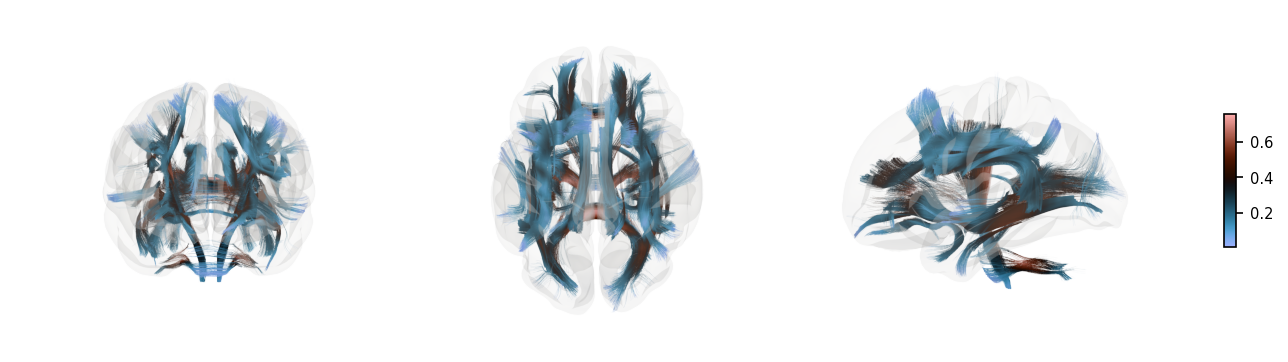

In [4]:
# fetch an example 3D fractional anisotropy (FA) volume from neurovault
fa_url = "https://neurovault.org/media/images/264/JHU-ICBM-FA-2mm.nii.gz"
fa_path = pooch.retrieve(url=fa_url, known_hash=None, path=pooch.os_cache("yabplot"), 
                         fname="sample_fa_map.nii.gz")

# sample the volume across all tracts in the atlas
# this returns a dictionary mapping tract names to their 1D scalar arrays.
tract_data = yab.project_vol2tract_atlas(nii_path=fa_path, atlas='xtract_medium')

# plot the tractometry
ax = yab.plot_tracts(
    atlas='xtract_medium', 
    data=tract_data, 
    views=['anterior', 'superior', 'left_lateral'], 
    bmesh='pial',
    cmap='berlin'
)

## 2. mapping a single tract
if you only care about one specific pathway (or if you are using a custom local `.trk` file), you can map it individually using `project_vol2tract`.

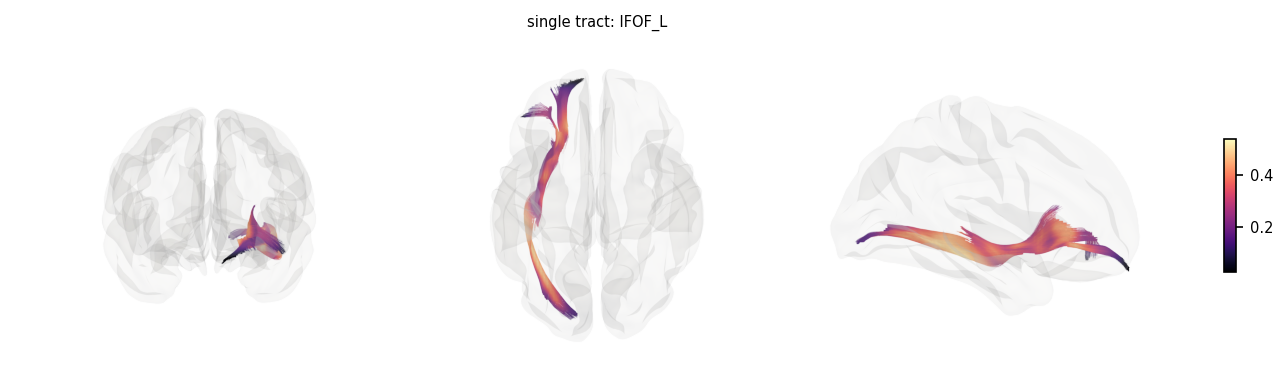

In [5]:
# locate the specific .trk file you want to map
atlas_dir = yab.data._resolve_resource_path('xtract_large', 'tracts')
tract_files = yab.data._find_tract_files(atlas_dir)

# lets get the path to the left inferior fronto-occipital fasciculus (IFOF)
cst_l_path = tract_files['IFOF_L']

# sample the volume for just this one tract and add it to dictionary
sampled_array = yab.project_vol2tract(trk_path=cst_l_path, nii_path=fa_path)
single_tract_data = {'IFOF_L': sampled_array}

# plot
ax = yab.plot_tracts(
    atlas='xtract_large', 
    data=single_tract_data, 
    views=['anterior', 'superior', 'left_medial'], 
    nan_alpha=0.0, # hide the other tracts
    cmap='magma',
)
ax = ax.set_title("single tract: IFOF_L", fontsize=7)

## 3. plotting pre-computed MRtrix3 .tsf files
if you are already use MRtrix3, you might have already mapped your metrics using the tcksample command line tool, resulting in binary .tsf (track scalar files). yabplot includes a native parser so you don't have to write your own data loaders.

In [8]:
from yabplot.utils import load_tsf

# assuming you have a local .tsf file generated by MRtrix3:
# tsf_path = '/path/to/your/custom_metric.tsf'

# read the binary file directly into a flat numpy array
# my_tsf_data = load_tsf(tsf_path)

# assign it to the matching tract name
# custom_tract_data = {'my_custom_tract': my_tsf_data}

# plot
# yab.plot_tracts(
#     custom_atlas_path='/path/to/your/custom_tract.tck',
#     data=custom_tract_data,
#     cmap='coolwarm'
# )